<a href="https://colab.research.google.com/github/Ivykimathi/ATM/blob/master/IVY_KAJUJU_SPARK_ASSIGNMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pyspark seaborn

In [34]:
# import libraries
from pyspark.sql import SparkSession
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql.functions import (col,count,when,isnan,avg,min,max)

spark = SparkSession.builder \
    .appName("Restaurant Revenue Prediction") \
    .getOrCreate()

In [9]:
# upload the csv
from google.colab import files

uploaded = files.upload()

Saving restaurant_data.csv to restaurant_data (1).csv


In [10]:
# load csv using spark
df = spark.read.csv( file_name, header=True,inferSchema=True )
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [11]:
# test show 10 rows
df.show(10)

+------------+--------+--------+------+----------------+------------------+----------------+----------------------+---------------------+-----------------+------------------+--------------+---------------------+--------------------+--------------------+--------------------+----------+
|        Name|Location| Cuisine|Rating|Seating Capacity|Average Meal Price|Marketing Budget|Social Media Followers|Chef Experience Years|Number of Reviews| Avg Review Length|Ambience Score|Service Quality Score|Parking Availability|Weekend Reservations|Weekday Reservations|   Revenue|
+------------+--------+--------+------+----------------+------------------+----------------+----------------------+---------------------+-----------------+------------------+--------------+---------------------+--------------------+--------------------+--------------------+----------+
|Restaurant 0|   Rural|Japanese|   4.0|              38|             73.98|            2224|                 23406|                   13|     

In [15]:
# check for duplictes
total_rows = df.count()
unique_rows = df.dropDuplicates().count()

duplicate_count = total_rows - unique_rows

print("Total rows:-", total_rows)
print("Unique rows:-", unique_rows)
print("Duplicate rows:-", duplicate_count)

Total rows:- 8368
Unique rows:- 8368
Duplicate rows:- 0


In [23]:
# check for bias:
#  check if data is heavily dominated by 1 category
# import round
from pyspark.sql.functions import round

# find total rows
total_rows = df.count()
# find categorical columns
categorical_columns = [col_name for col_name, col_type in df.dtypes if col_type == 'string']
print("Categorical columns:-", categorical_columns)

# check distribution for each category
for col_name in categorical_columns:
    category_counts = (
        df.groupBy(col_name)
        .count()
        .withColumn(
            "percentage",
            round((col("count") / total_rows) * 100, 2)
        )
        .orderBy("count", ascending=False)
    )
    category_counts.show(truncate=False)


Categorical columns:- ['Name', 'Location', 'Cuisine', 'Parking Availability']
+---------------+-----+----------+
|Name           |count|percentage|
+---------------+-----+----------+
|Restaurant 39  |1    |0.01      |
|Restaurant 213 |1    |0.01      |
|Restaurant 368 |1    |0.01      |
|Restaurant 437 |1    |0.01      |
|Restaurant 500 |1    |0.01      |
|Restaurant 566 |1    |0.01      |
|Restaurant 574 |1    |0.01      |
|Restaurant 920 |1    |0.01      |
|Restaurant 1178|1    |0.01      |
|Restaurant 1180|1    |0.01      |
|Restaurant 1574|1    |0.01      |
|Restaurant 1871|1    |0.01      |
|Restaurant 2363|1    |0.01      |
|Restaurant 2474|1    |0.01      |
|Restaurant 2669|1    |0.01      |
|Restaurant 2818|1    |0.01      |
|Restaurant 3383|1    |0.01      |
|Restaurant 3390|1    |0.01      |
|Restaurant 3543|1    |0.01      |
|Restaurant 3963|1    |0.01      |
+---------------+-----+----------+
only showing top 20 rows
+--------+-----+----------+
|Location|count|percentage|
+

In [25]:
# check for outliers: data values that are unusually far from the rest
# first identify numerical values
numeric_columns = [
    col_name for col_name, col_type in df.dtypes
    if col_type in ['int', 'bigint', 'float', 'double']
]

print("Numerical columns:", numeric_columns)

Numerical columns: ['Rating', 'Seating Capacity', 'Average Meal Price', 'Marketing Budget', 'Social Media Followers', 'Chef Experience Years', 'Number of Reviews', 'Avg Review Length', 'Ambience Score', 'Service Quality Score', 'Weekend Reservations', 'Weekday Reservations', 'Revenue']


In [26]:
# check iqr for each column
from pyspark.sql.functions import col

for col_name in numeric_columns:

    quantiles = df.approxQuantile( col_name, [0.25, 0.75], 0.05 )

    Q1 = quantiles[0]
    Q3 = quantiles[1]

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {col_name}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")


Column: Rating
Q1: 3.5
Q3: 4.4
IQR: 0.9000000000000004
Lower Bound: 2.1499999999999995
Upper Bound: 5.750000000000001

Column: Seating Capacity
Q1: 46.0
Q3: 73.0
IQR: 27.0
Lower Bound: 5.5
Upper Bound: 113.5

Column: Average Meal Price
Q1: 35.81
Q3: 58.23
IQR: 22.419999999999995
Lower Bound: 2.180000000000007
Upper Bound: 91.85999999999999

Column: Marketing Budget
Q1: 1931.0
Q3: 3779.0
IQR: 1848.0
Lower Bound: -841.0
Upper Bound: 6551.0

Column: Social Media Followers
Q1: 23104.0
Q3: 42241.0
IQR: 19137.0
Lower Bound: -5601.5
Upper Bound: 70946.5

Column: Chef Experience Years
Q1: 5.0
Q3: 14.0
IQR: 9.0
Lower Bound: -8.5
Upper Bound: 27.5

Column: Number of Reviews
Q1: 290.0
Q3: 731.0
IQR: 441.0
Lower Bound: -371.5
Upper Bound: 1392.5

Column: Avg Review Length
Q1: 116.1238746035763
Q3: 229.0141899577291
IQR: 112.89031535415279
Lower Bound: -53.21159842765289
Upper Bound: 398.34966298895824

Column: Ambience Score
Q1: 3.5
Q3: 7.5
IQR: 4.0
Lower Bound: -2.5
Upper Bound: 13.5

Column: Se

In [30]:
# display outliers
for col_name in numeric_columns:
    quantiles = df.approxQuantile( col_name, [0.25, 0.75], 0.05 )

    Q1 = quantiles[0]
    Q3 = quantiles[1]

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nOutliers in {col_name}:")
    df.filter(
        (col(col_name) < lower_bound) |
        (col(col_name) > upper_bound)
    ).select(col_name).show()


Outliers in Rating:
+------+
|Rating|
+------+
+------+


Outliers in Seating Capacity:
+----------------+
|Seating Capacity|
+----------------+
+----------------+


Outliers in Average Meal Price:
+------------------+
|Average Meal Price|
+------------------+
+------------------+


Outliers in Marketing Budget:
+----------------+
|Marketing Budget|
+----------------+
|            6787|
|            8511|
|            6712|
|            6923|
|            6601|
|            8060|
|            8349|
|            7011|
|            6809|
|            9150|
|            8378|
|            7924|
|            6840|
|            7087|
|            7490|
|            7360|
|            6967|
|            7781|
|            9699|
|            6580|
+----------------+
only showing top 20 rows

Outliers in Social Media Followers:
+----------------------+
|Social Media Followers|
+----------------------+
|                 75378|
|                 88420|
|                 72937|
|                

In [31]:
# split dataset to training and testing
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# show the splited data
print("Total rows:", df.count())
print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

Total rows: 8368
Training rows: 6764
Testing rows: 1604


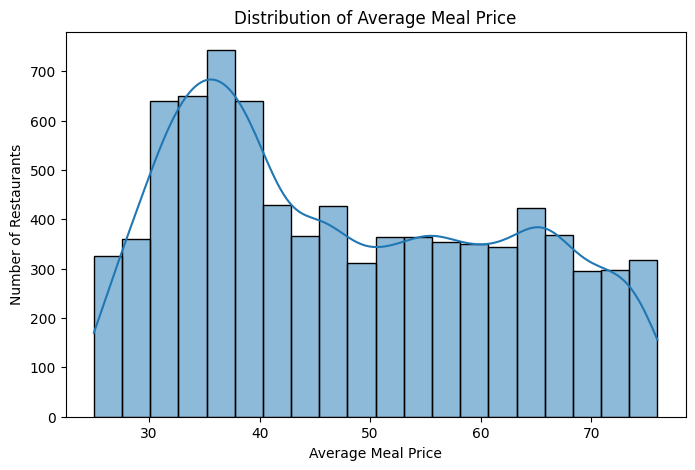

In [40]:
# visualize
pandas_df = df.toPandas()
# print(pandas_df.columns.tolist())
# print(pandas_df.dtypes)

# average meal pprice
plt.figure(figsize=(8, 5))

sns.histplot(
    data=pandas_df,
    x="Average Meal Price",
    bins=20,
    kde=True
)

plt.title("Distribution of Average Meal Price")
plt.xlabel("Average Meal Price")
plt.ylabel("Number of Restaurants")

plt.show()

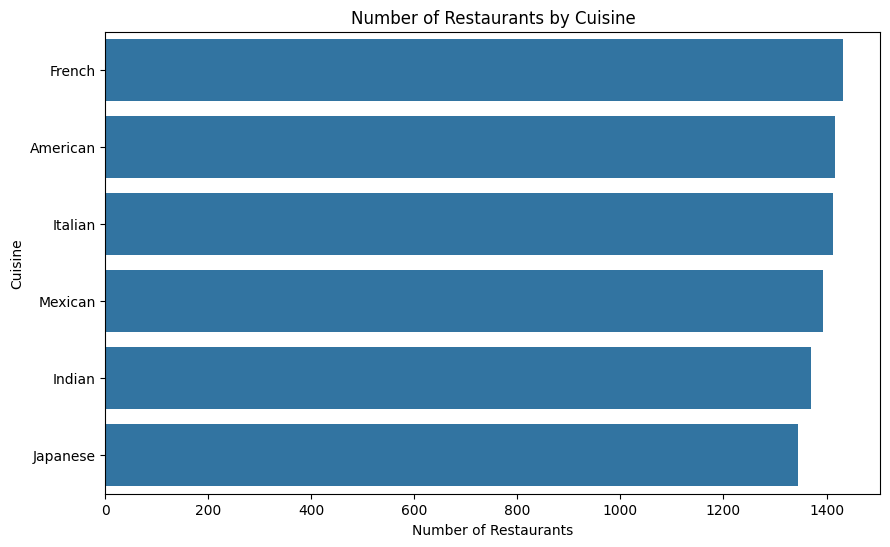

In [45]:
# Number of Restaurants by Cuisine
plt.figure(figsize=(10, 6))

sns.countplot(
    data=pandas_df,
    y="Cuisine",
    order=pandas_df["Cuisine"].value_counts().index
)

plt.title("Number of Restaurants by Cuisine")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.show()

In [46]:
# save the cleaned dataset
df.coalesce(1).write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("cleaned_restaurant_dataset")